In [1]:
print("Plant Disease Detection Project Started!")

Plant Disease Detection Project Started!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
try:
    import sklearn
    print("Scikit-learn is available!")
    print("Version:", sklearn.__version__)
except ImportError:
    print("Scikit-learn is NOT available.")

Scikit-learn is available!
Version: 1.8.0


In [4]:
# Plant Disease Detection - Project Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Machine Learning setup completed successfully!")

Machine Learning setup completed successfully!


In [5]:
# Create a simple plant disease dataset

data = {
    "leaf_spots": [1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
                   1, 0, 0, 1, 1, 0, 1, 0, 1, 0],

    "yellow_leaves": [1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
                      1, 0, 1, 1, 0, 0, 1, 0, 1, 0],

    "wilting": [0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
                1, 0, 1, 1, 0, 1, 1, 0, 1, 0],

    "leaf_damage": [1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
                    1, 0, 1, 1, 0, 1, 1, 0, 1, 0],

    "disease": [
        "Bacterial Spot", "Bacterial Spot",
        "Healthy", "Powdery Mildew",
        "Bacterial Spot", "Healthy",
        "Bacterial Spot", "Healthy",
        "Bacterial Spot", "Healthy",
        "Bacterial Spot", "Healthy",
        "Powdery Mildew", "Powdery Mildew",
        "Healthy", "Powdery Mildew",
        "Bacterial Spot", "Healthy",
        "Powdery Mildew", "Healthy"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of samples:", len(df))

df.head(10)

Dataset created successfully!
Number of samples: 20


,leaf_spots,yellow_leaves,wilting,leaf_damage,disease
0,1,1,0,1,Bacterial Spot
1,1,1,1,1,Bacterial Spot
2,0,0,0,0,Healthy
3,0,1,1,0,Powdery Mildew
4,1,0,1,1,Bacterial Spot
5,0,1,0,0,Healthy
6,1,1,1,1,Bacterial Spot
7,0,0,0,0,Healthy
8,1,1,1,1,Bacterial Spot
9,0,0,0,0,Healthy


In [6]:
# Separate features (X) and target (y)

X = df[["leaf_spots", "yellow_leaves", "wilting", "leaf_damage"]]
y = df["disease"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Training samples: 16
Testing samples: 4
Random Forest model trained successfully!


In [7]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Actual diseases:")
print(y_test.values)

print("\nPredicted diseases:")
print(y_pred)

Actual diseases:
<StringArray>
['Healthy', 'Bacterial Spot', 'Powdery Mildew', 'Healthy']
Length: 4, dtype: str

Predicted diseases:
['Healthy' 'Bacterial Spot' 'Bacterial Spot' 'Healthy']


In [8]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Plant Disease Detection Model")
print("------------------------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100, "%")

Plant Disease Detection Model
------------------------------
Accuracy: 0.75
Accuracy (%): 75.0 %


In [9]:
# Generate classification report

print("Classification Report")
print("---------------------")

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Classification Report
---------------------
                precision    recall  f1-score   support

Bacterial Spot       0.50      1.00      0.67         1
       Healthy       1.00      1.00      1.00         2
Powdery Mildew       0.00      0.00      0.00         1

      accuracy                           0.75         4
     macro avg       0.50      0.67      0.56         4
  weighted avg       0.62      0.75      0.67         4



Confusion Matrix
----------------
[[1 0 0]
 [0 2 0]
 [1 0 0]]


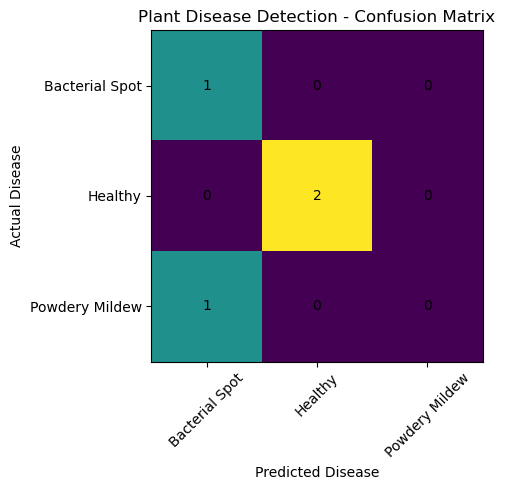

In [10]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print("----------------")
print(cm)

# Display the confusion matrix as a graph

plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Plant Disease Detection - Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

classes = model.classes_

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# Add numbers inside the cells
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [11]:
# Plant Disease Prediction Function

def predict_disease(leaf_spots, yellow_leaves, wilting, leaf_damage):
    
    symptoms = pd.DataFrame([{
        "leaf_spots": leaf_spots,
        "yellow_leaves": yellow_leaves,
        "wilting": wilting,
        "leaf_damage": leaf_damage
    }])
    
    prediction = model.predict(symptoms)[0]
    
    return prediction


# Example prediction

result = predict_disease(
    leaf_spots=1,
    yellow_leaves=1,
    wilting=0,
    leaf_damage=1
)

print("Plant Disease Prediction")
print("-------------------------")
print("Predicted Disease:", result)

Plant Disease Prediction
-------------------------
Predicted Disease: Bacterial Spot


In [13]:
# Interactive Plant Disease Predictor

print("🌱 PLANT DISEASE DETECTION SYSTEM")
print("----------------------------------")

print("Enter 1 if the symptom is present, otherwise enter 0.")

leaf_spots = int(input("Leaf spots present? (1/0): "))
yellow_leaves = int(input("Yellow leaves present? (1/0): "))
wilting = int(input("Plant wilting? (1/0): "))
leaf_damage = int(input("Leaf damage present? (1/0): "))

prediction = predict_disease(
    leaf_spots,
    yellow_leaves,
    wilting,
    leaf_damage
)

print("\n🌿 Prediction Result")
print("-------------------")
print("Predicted Disease:", prediction)

🌱 PLANT DISEASE DETECTION SYSTEM
----------------------------------
Enter 1 if the symptom is present, otherwise enter 0.


Leaf spots present? (1/0):  Leaf spots: 1 Yellow leaves: 1 Wilting: 0 Leaf damage: 1


<class 'ValueError'>: invalid literal for int() with base 10: 'Leaf spots: 1 Yellow leaves: 1 Wilting: 0 Leaf damage: 1'

In [17]:
# Interactive Plant Disease Predictor

print("🌱 PLANT DISEASE DETECTION SYSTEM")
print("----------------------------------")

print("Enter 1 if the symptom is present, otherwise enter 0.")

leaf_spots = int(input("Leaf spots present? (1/0): "))
yellow_leaves = int(input("Yellow leaves present? (1/0): "))
wilting = int(input("Plant wilting? (1/0): "))
leaf_damage = int(input("Leaf damage present? (1/0): "))

prediction = predict_disease(
    leaf_spots,
    yellow_leaves,
    wilting,
    leaf_damage
)

print("\n🌿 Prediction Result")
print("-------------------")
print("Predicted Disease:", prediction)

🌱 PLANT DISEASE DETECTION SYSTEM
----------------------------------
Enter 1 if the symptom is present, otherwise enter 0.


Leaf spots present? (1/0):  1
Yellow leaves present? (1/0):  1
Plant wilting? (1/0):  0
Leaf damage present? (1/0):  1



🌿 Prediction Result
-------------------
Predicted Disease: Bacterial Spot


In [18]:
# Model Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("🌱 Plant Disease Detection Model")
print("-------------------------------")
print("Model Accuracy:", accuracy * 100, "%")

🌱 Plant Disease Detection Model
-------------------------------
Model Accuracy: 75.0 %


In [19]:
# Project Summary

print("🌱 PLANT DISEASE DETECTION SYSTEM")
print("=" * 40)
print("Model Used: Random Forest Classifier")
print("Task: Plant Disease Classification")
print("Input: Plant leaf symptoms")
print("Output: Predicted disease")
print("Classes: Bacterial Spot, Healthy, Powdery Mildew")
print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("=" * 40)
print("Project completed successfully!")

🌱 PLANT DISEASE DETECTION SYSTEM
Model Used: Random Forest Classifier
Task: Plant Disease Classification
Input: Plant leaf symptoms
Output: Predicted disease
Classes: Bacterial Spot, Healthy, Powdery Mildew
Model Accuracy: 75.0 %
Project completed successfully!
